In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
unem_df= pd.read_csv("Unemployment in India.csv")
print(unem_df.head())
print(unem_df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data colu

In [3]:
unemrate_df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
print(unemrate_df.head())
print(unemrate_df.info())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

## Data Cleaning 

In [4]:
print(unem_df.isnull().sum())
print("Shape of this dataset: ",unem_df.shape)

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64
Shape of this dataset:  (768, 7)


In [5]:
print(unemrate_df.isnull().sum())
print('Shape of this dataset :',unemrate_df.shape)

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64
Shape of this dataset : (267, 9)


In [6]:
def clean_df(df): 
    # Strip spaces from columns name
    df.columns= df.columns.str.strip()

    # Drop completely entire row 
    df= df.dropna(how='all')

    # Strip spaces from object columns 
    for col in df.select_dtypes('object').columns : 
        df[col] = df[col].str.strip()

    #Convert Date column into Datetime format 
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

    # Remove duplicates 
    df= df.drop_duplicates()

    # Sort Values by dates 
    df = df.sort_values('Date')

    return df


unem_df = clean_df(unem_df)
unemrate_df = clean_df(unemrate_df)

C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3118081548.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.strip()
C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3118081548.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [7]:
unemrate_df['Frequency'].replace({'M':"Month"}, inplace=True)

C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3167086076.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unemrate_df['Frequency'].replace({'M':"Month"}, inplace=True)


## EDA

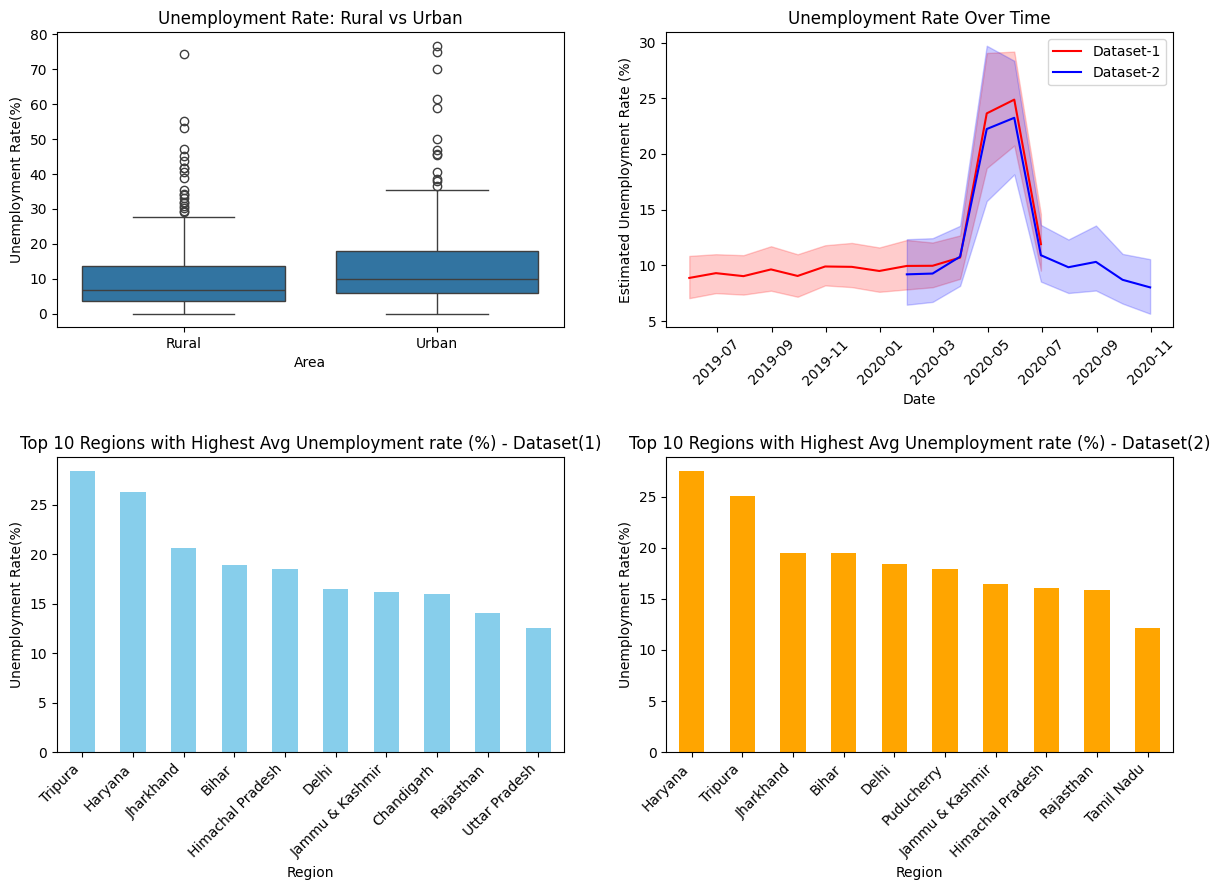

In [18]:
# Unemployment Rate: Rural vs Urban
plt.figure(figsize=(12,9))
plt.subplot(2, 2, 1)
plt.title("Unemployment Rate: Rural vs Urban")
sns.boxplot(x='Area',y='Estimated Unemployment Rate (%)', data=unem_df)
plt.ylabel('Unemployment Rate(%)')

# Average Unemployment Rate Over Time
plt.subplot(2,2,2)
plt.title("Unemployment Rate Over Time")
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unem_df, label='Dataset-1', color='red' )
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unemrate_df, label='Dataset-2', color='blue')
plt.xticks(rotation=45)

# Top 10 Regions with Highest Avg Unemployment rate (%) - Dataset(1)
top_region_ue1 = unem_df.groupby('Region')["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)
top_region_ue2 = unemrate_df.groupby('Region')["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)
plt.subplot(2,2,3)
plt.title("Top 10 Regions with Highest Avg Unemployment rate (%) - Dataset(1)")
top_region_ue1.plot(kind='bar', color='skyblue')
plt.ylabel('Unemployment Rate(%)')
plt.xticks(rotation=45, ha='right')

# Top 10 Regions with Highest Avg Unemployment rate (%) - Dataset(2)
plt.subplot(2,2,4)
plt.title("Top 10 Regions with Highest Avg Unemployment rate (%) - Dataset(2)")
top_region_ue2.plot(kind='bar', color='orange')
plt.ylabel('Unemployment Rate(%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout(h_pad=2,w_pad=4)
plt.show()

C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3565015514.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unemrate_df, x='Region.1', y='Estimated Unemployment Rate (%)', palette='viridis')
C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3565015514.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_order,y=month_unem_avg.values, palette='viridis')
C:\Users\AKIB\AppData\Local\Temp\ipykernel_1332\3565015514.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x=month_order,y=month_LPR_avg,palette='viridis')


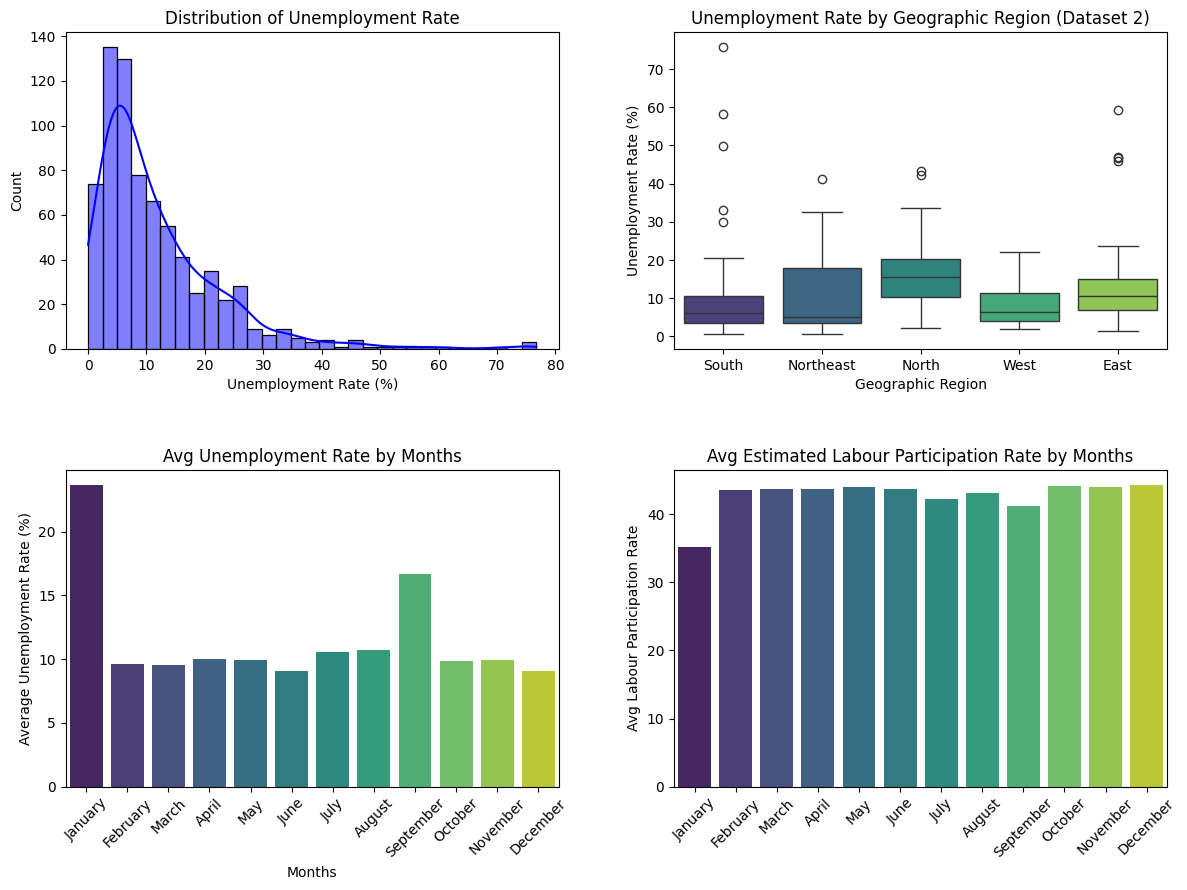

In [19]:
# Distribution of Unemployment Rate
plt.figure(figsize=(12,9))
plt.subplot(2,2,1)
plt.title('Distribution of Unemployment Rate')
sns.histplot(unem_df['Estimated Unemployment Rate (%)'], color='blue', kde=True)
plt.xlabel('Unemployment Rate (%)')

# Region-wise comparison (using df2 for broader regions)
plt.subplot(2,2,2)
sns.boxplot(data=unemrate_df, x='Region.1', y='Estimated Unemployment Rate (%)', palette='viridis')
plt.title('Unemployment Rate by Geographic Region (Dataset 2)')
plt.xlabel('Geographic Region')
plt.ylabel('Unemployment Rate (%)')

# Avg Unemployment Rate by Months
plt.subplot(2,2,3)
unem_df['Month']= unem_df['Date'].dt.month_name()
month_unem_avg = unem_df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.title("Avg Unemployment Rate by Months")
sns.barplot(x=month_order,y=month_unem_avg.values, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel('Months')
plt.ylabel('Average Unemployment Rate (%)')

# Avg Estimated Labour Participation Rate by Months
plt.subplot(2,2,4)
month_LPR_avg = unem_df.groupby('Month')['Estimated Labour Participation Rate (%)'].mean() 
plt.title("Avg Estimated Labour Participation Rate by Months")
sns.barplot( x=month_order,y=month_LPR_avg,palette='viridis')
plt.ylabel("Avg Labour Participation Rate")
plt.xticks(rotation=45)

plt.tight_layout(h_pad=4,w_pad=4)
plt.show()

##  Impact of Covid-19 on unemployment rates

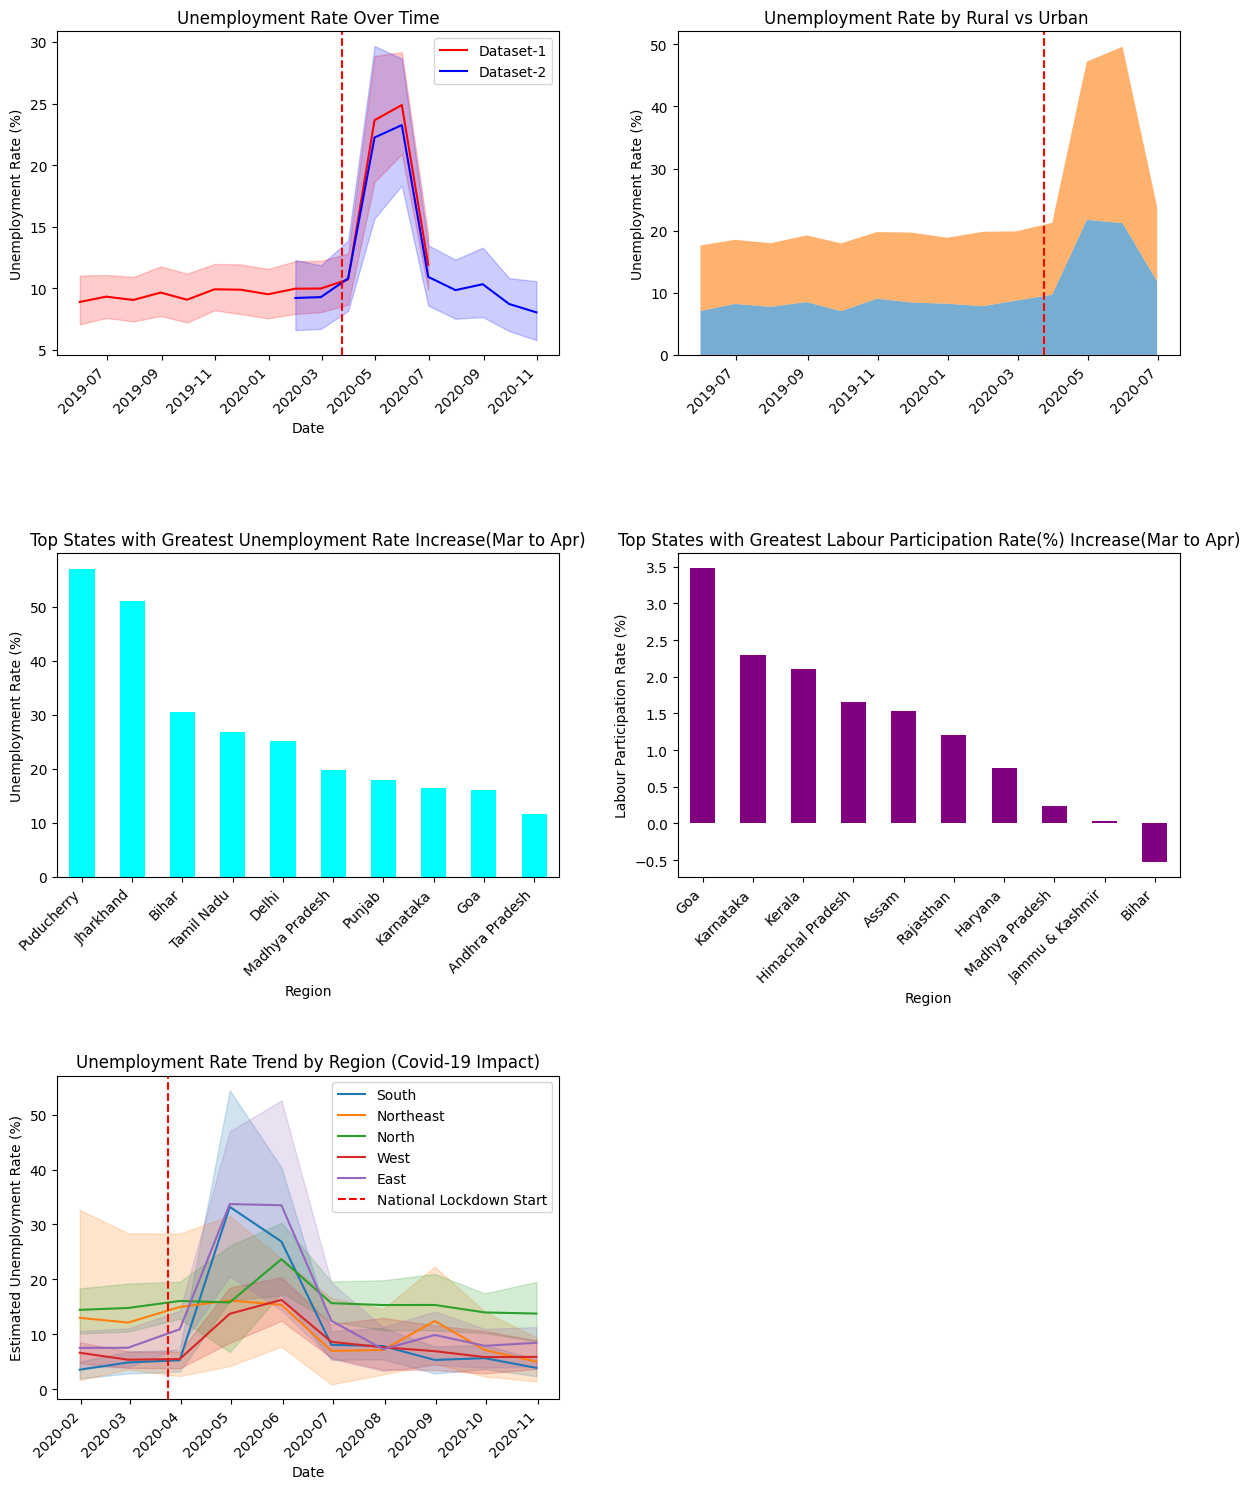

In [20]:
plt.figure(figsize=(12,15))

# Average Unemployment Rate Over Time
# National lockdown starts at 2020-03-24
plt.subplot(3,2,1)
plt.title("Unemployment Rate Over Time")
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unem_df, label='Dataset-1', color='red' )
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=unemrate_df, label='Dataset-2', color='blue')
plt.axvline( pd.Timestamp('2020-03-24'), color='red', linestyle='--', label='National Lockdown Start' )
plt.xticks(rotation=45, ha='right')
plt.ylabel('Unemployment Rate (%)')

# Unemployment Rate by Rural vs Urban 
unem_df_pivot = unem_df.groupby(['Date','Area'])['Estimated Unemployment Rate (%)'].mean().unstack()
plt.subplot(3,2,2)
plt.title("Unemployment Rate by Rural vs Urban ")
plt.stackplot(unem_df_pivot.index, unem_df_pivot['Rural'], unem_df_pivot['Urban'], labels=['Rural','Urban'], alpha=0.6)
plt.axvline( pd.Timestamp('2020-03-24'), color='red', linestyle='--', label='National Lockdown Start' )
plt.xticks(rotation=45, ha='right')
plt.ylabel('Unemployment Rate (%)')

# Top 10 States with Greatest Unemployment Rate Increase during lockdown (March to April)
unemrate_mar = unemrate_df[unemrate_df['Date']=='2020-03-31'].groupby('Region')['Estimated Unemployment Rate (%)'].mean() 
unemrate_may = unemrate_df[unemrate_df['Date']=='2020-05-31'].groupby('Region')['Estimated Unemployment Rate (%)'].mean() 
increase = (unemrate_may - unemrate_mar).sort_values(ascending=False).head(10)
plt.subplot(3,2,3)
plt.title("Top States with Greatest Unemployment Rate Increase(Mar to Apr)")
increase.plot(kind='bar', color='cyan')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Unemployment Rate (%)')

# Top States with Greatest Labour Participation Rate (%) Increase(March to April)
elpr_mar = unemrate_df[unemrate_df['Date']=='2020-03-31'].groupby('Region')['Estimated Labour Participation Rate (%)'].mean() 
elpr_may = unemrate_df[unemrate_df['Date']=='2020-05-31'].groupby('Region')['Estimated Labour Participation Rate (%)'].mean() 
elpr_increase = (elpr_may - elpr_mar).sort_values(ascending=False).head(10)
plt.subplot(3,2,4)
plt.title("Top States with Greatest Labour Participation Rate(%) Increase(Mar to Apr)")
elpr_increase.plot(kind='bar', color='purple')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Labour Participation Rate (%)')

# Trend Analysis (Covid Impact)
plt.subplot(3,2,5)
sns.lineplot(data=unemrate_df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region.1')
plt.axvline( pd.Timestamp('2020-03-24'), color='red', linestyle='--', label='National Lockdown Start' )
plt.title('Unemployment Rate Trend by Region (Covid-19 Impact)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout(h_pad=4,w_pad=4)
plt.legend()
plt.show()

### While the COVID-19 impact was national, it was disproportionately severe in urban areas and hit specific states with extreme volatility and unprecedented spikes.

### Based on the analysis of the provided datasets, here are the key patterns and seasonal trends identified:

* Pre-Pandemic Stability : From May 2019 to February 2020, the unemployment rate remained relatively steady, averaging approximately 9.51%. This indicates a baseline level of structural unemployment before any external shocks.

* The Lockdown Shock : A massive, non-seasonal spike occurred in April and May 2020, with rates surging to an average of 24.26%. This sudden climb coincided directly with the start of national lockdown measures.

* Urban vs. Rural Disparity : Urban areas consistently faced higher unemployment rates (avg. 13.17%) compared to rural areas (avg. 10.32%). The urban sector also experienced a much sharper and more volatile increase during the lockdown peak.

* Regional Extremes : The impact was highly uneven across geography; regions like Puducherry and Jharkhand saw unprecedented spikes exceeding 50 percentage points. Other states maintained much lower, more stable figures throughout the same period.

* V-Shaped Recovery : By late 2020, the data shows a rapid correction as rates dropped back to roughly 9.22%. This indicates that the massive spike was a temporary reaction to restrictions rather than a permanent structural shift.

* Independent Labour Perticipate : Labour participate doesn't affect on unemployment rate even not in lockdown. That says, Labour are waiting for work but they didn't get any job

In [23]:
print("Top regions by unemployment rate by dataset-1:")
print(top_region_ue1)

Top regions by unemployment rate by dataset-1:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [24]:
print("Top regions by unemployment rate by dataset-1:")
top_region_ue2

Top regions by unemployment rate by dataset-1:


Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

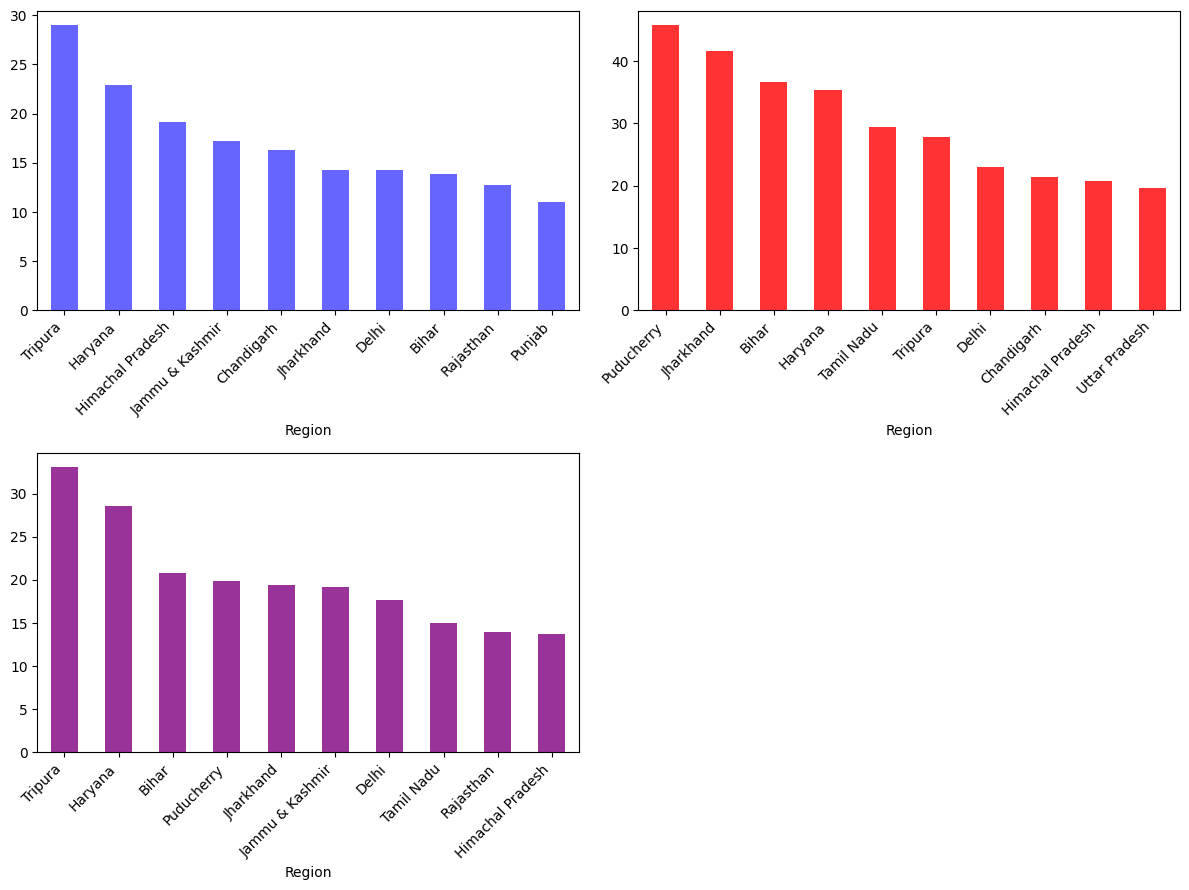

In [50]:
unem_bf_mar = unem_df[unem_df['Date']<'2020-03-24'].groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10) 
unem_b_mar_apr = unem_df[(unem_df['Date'] >= '2020-03-24') & (unem_df['Date'] <= '2020-05-31')].groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10) 
unem_af_apr= unemrate_df[unemrate_df['Date'] < '2020-05-31'].groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10) 

plt.figure(figsize=(12,9))
plt.subplot(2,2,1)
unem_bf_mar.plot(kind='bar', color='blue', alpha=0.6)
plt.xticks(rotation=45, ha='right')

plt.subplot(2,2,2)
unem_b_mar_apr.plot(kind='bar', color='red', alpha=0.8) 
plt.xticks(rotation=45, ha='right')

plt.subplot(2,2,3)
unem_af_apr.plot(kind='bar', color='purple', alpha=0.8)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##  Insights that could inform economic and social policies

* A sharp spike in April 2020 indicates the need for "automatic stabilizers"—policies that trigger financial support immediately when unemployment exceeds a certain threshold.
* Regions with consistently high rates (e.g., North or East) may require long-term structural investment in industries that are less sensitive to lockdowns, such as IT or agriculture-based manufacturing.
* If urban unemployment stays high while rural unemployment drops, it suggests a "reverse migration" effect. Social policies might then need to shift focus toward Urban Employment Guarantee schemes to support returning migrants.
* States with low LPR and high Unemployment are in a "double jeopardy" state. Policy should focus on vocational training and female workforce participation to bring people back into the active labor pool.
* Some states like - Bihar, Puducheery, Tamil Nadu gains unemployment after lockdown. They should developed their economy thus next pandamic doesn't affect that much anymore